# BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding

This notebook implements the BERT algorithm described in:

Devlin et al., "BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding."

We will implement the system incrementally, following the major components described in the paper.

The implementation will be developed in levels:

1. Basic infrastructure
2. Tokenization
3. MLM and NSP data preparation
4. Transformer architecture
5. BERT pretraining
6. Pretraining validation and scaling
7. Fine-tuning
8. Downstream NLP tasks
9. Experimental reproduction

## 1. Installing the required libraries

This cell installs the libraries required for our miniature BERT implementation.

We will use PyTorch for model development and training, Hugging Face Datasets for loading the text corpus, and supporting libraries for data processing and reproducibility.

At this stage, we are preparing the environment only. We are not loading a pre-trained BERT model or training any neural network.


In [7]:
!pip -q install datasets tokenizers huggingface_hub

## 2. Configuring the experimental environment

This cell imports the required libraries and establishes the computation device.

We will use a GPU whenever Google Colab provides one, while keeping the implementation compatible with CPU execution for debugging. We also set fixed random seeds so that dataset preparation and subsequent experiments can be reproduced more consistently.

Reproducibility is important because we will later compare different model configurations and pre-training strategies.

In [2]:
import os
import random
import re
import json
from pathlib import Path

import numpy as np
import torch

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
Device: cuda
GPU: Tesla T4


## 3. Loading the WikiText-103 raw corpus

The original BERT paper uses a document-level corpus to sample contiguous text spans for pre-training. We will use WikiText-103 raw as a smaller, practical corpus for our experiment.

This cell downloads the raw training split and inspects its structure. We will retain the original document ordering at this stage rather than randomly shuffling individual lines.

The dataset is loaded from Hugging Face Datasets, while the BERT-specific sentence-pair sampling and masking procedures will be implemented later.

In [8]:
from datasets import load_dataset

dataset = load_dataset(
    "Salesforce/wikitext",
    "wikitext-103-raw-v1",
    split="train"
)

print(dataset)
print(dataset[0])

wikitext-103-raw-v1/train-00000-of-00002(…): reconstructing file:   0%|          |  0.00B /  157MB            

wikitext-103-raw-v1/train-00000-of-00002(…): downloading bytes:           |  0.00B            

wikitext-103-raw-v1/train-00001-of-00002(…): reconstructing file:   0%|          |  0.00B /  157MB            

wikitext-103-raw-v1/train-00001-of-00002(…): downloading bytes:           |  0.00B            

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/1801350 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

Dataset({
    features: ['text'],
    num_rows: 1801350
})
{'text': ''}


## 4. Reconstructing and cleaning documents

BERT's pre-training procedure samples two text spans from the corpus, where the second span may be the actual continuation of the first or a randomly selected span. Preserving document boundaries gives us a meaningful basis for implementing this procedure.

This cell groups consecutive raw entries into documents using blank lines as separators. It removes empty entries and normalizes basic whitespace while avoiding aggressive text transformations that could remove useful language information.

We will also apply a character budget to control the amount of data used in our first Colab experiment. The actual number of tokens will be measured later after we implement the tokenizer.

In [9]:
raw_lines = [row["text"] for row in dataset]

documents = []
current_document = []

for line in raw_lines:
    line = line.strip()

    if not line:
        if current_document:
            documents.append(" ".join(current_document))
            current_document = []
    else:
        current_document.append(line)

# Add the final document if needed
if current_document:
    documents.append(" ".join(current_document))

# Basic cleaning
cleaned_documents = []

for doc in documents:
    doc = re.sub(r"\s+", " ", doc).strip()

    if len(doc) > 0:
        cleaned_documents.append(doc)

print("Number of reconstructed documents:", len(cleaned_documents))
print("First document preview:")
print(cleaned_documents[0][:500])

Number of reconstructed documents: 571551
First document preview:
= Valkyria Chronicles III =


## 5. Selecting a manageable training corpus

The original BERT model was trained on a corpus containing approximately 3.3 billion words. Training at that scale is not appropriate for our Colab experiment.

We will create a configurable subset based on the cumulative number of characters, rather than selecting a fixed number of documents without checking their content.

The initial budget is approximately 20 million characters. We will measure the resulting dataset size and later verify whether the vocabulary coverage and training behavior are adequate.

The validation data will be held out at the document level so that documents are not split into both training and validation sets.

In [10]:
MAX_CHARS = 20_000_000

selected_documents = []
total_chars = 0

for doc in cleaned_documents:
    if total_chars + len(doc) > MAX_CHARS:
        break

    selected_documents.append(doc)
    total_chars += len(doc)

print("Selected documents:", len(selected_documents))
print("Total characters:", total_chars)
print("Approximate size in MB:", round(total_chars / 1_000_000, 2))

Selected documents: 21534
Total characters: 19996876
Approximate size in MB: 20.0


## 6. Splitting the corpus into training and validation data

We will divide the selected documents into training and validation sets.

The split is performed at the document level to reduce the chance of placing overlapping portions of the same document into both sets. This is important because a validation set should provide a meaningful indication of how the model performs on text it has not trained on.

We use a 90/10 split for our initial experiment. The validation set will be used to track the MLM and NSP losses later, and it will not be used to update model parameters.

In [12]:
import random

# Use a local copy so the selected documents remain unchanged.
split_documents = selected_documents.copy()

random.Random(SEED).shuffle(split_documents)

split_index = int(0.9 * len(split_documents))

train_documents = split_documents[:split_index]
val_documents = split_documents[split_index:]

print("Training documents:", len(train_documents))
print("Validation documents:", len(val_documents))

train_chars = sum(len(doc) for doc in train_documents)
val_chars = sum(len(doc) for doc in val_documents)

print("Training characters:", train_chars)
print("Validation characters:", val_chars)

Training documents: 19380
Validation documents: 2154
Training characters: 18036862
Validation characters: 1960014


## 7. Inspecting the corpus statistics

Before proceeding to tokenizer construction, we need to understand the size and distribution of our data.

This cell reports the number of documents, total characters, and basic document-length statistics for both splits. These statistics will help us identify potential data problems such as empty documents, unusually short entries, or a validation set that is too small.

The statistics are character-based at this stage. Once we build our tokenizer, we will add token-level statistics and use those to estimate the number of training sequences.

In [13]:
def summarize_documents(name, documents):
    lengths = np.array([len(doc) for doc in documents])

    print(f"\n{name}")
    print("-" * 40)
    print("Documents:", len(documents))
    print("Total characters:", int(lengths.sum()))
    print("Average characters:", round(lengths.mean(), 2))
    print("Median characters:", int(np.median(lengths)))
    print("Minimum characters:", int(lengths.min()))
    print("Maximum characters:", int(lengths.max()))

summarize_documents("Training set", train_documents)
summarize_documents("Validation set", val_documents)


Training set
----------------------------------------
Documents: 19380
Total characters: 18036862
Average characters: 930.69
Median characters: 42
Minimum characters: 3
Maximum characters: 14132

Validation set
----------------------------------------
Documents: 2154
Total characters: 1960014
Average characters: 909.94
Median characters: 41
Minimum characters: 3
Maximum characters: 8614


## 8. Saving the prepared corpus

This cell saves the cleaned training and validation documents as JSON files.

Saving the data ensures that subsequent notebook runs can reuse the same dataset splits without repeatedly downloading and reconstructing the corpus.

We also save a small metadata file containing the seed and corpus configuration. This allows us to record the settings used for each experiment and helps maintain reproducibility throughout the project.

In [14]:
from pathlib import Path
import json

DATA_DIR = Path("/content/mini_bert_data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

with open(DATA_DIR / "train_documents.json", "w", encoding="utf-8") as f:
    json.dump(train_documents, f, ensure_ascii=False)

with open(DATA_DIR / "val_documents.json", "w", encoding="utf-8") as f:
    json.dump(val_documents, f, ensure_ascii=False)

metadata = {
    "seed": SEED,
    "max_chars": MAX_CHARS,
    "num_train_documents": len(train_documents),
    "num_val_documents": len(val_documents),
    "train_characters": train_chars,
    "val_characters": val_chars
}

with open(DATA_DIR / "metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("Saved files:")
for path in sorted(DATA_DIR.iterdir()):
    print(path.name)

Saved files:
metadata.json
train_documents.json
val_documents.json


## 9. Training a WordPiece Tokenizer

We will train a custom WordPiece tokenizer using only the training documents. The tokenizer uses the following special tokens:

`[PAD]`: Padding

`[UNK]`: Unknown token

`[CLS]`: Start of an input sequence

`[SEP]`: Separates sentence pairs

`[MASK]`: Used for Masked Language Modeling

We will use a vocabulary size of 8,000 tokens to keep the tokenizer suitable for Colab.

In [15]:
from tokenizers import Tokenizer
from tokenizers.models import WordPiece
from tokenizers.normalizers import BertNormalizer
from tokenizers.pre_tokenizers import BertPreTokenizer
from tokenizers.trainers import WordPieceTrainer
from pathlib import Path
import json

# Paths
DATA_DIR = Path("/content/mini_bert_data")
TOKENIZER_PATH = DATA_DIR / "tokenizer.json"

# Create WordPiece tokenizer
tokenizer = Tokenizer(
    WordPiece(unk_token="[UNK]")
)

# BERT-style normalization and pre-tokenization
tokenizer.normalizer = BertNormalizer(
    clean_text=True,
    handle_chinese_chars=True,
    strip_accents=None,
    lowercase=True
)

tokenizer.pre_tokenizer = BertPreTokenizer()

# Configure tokenizer training
special_tokens = [
    "[PAD]",
    "[UNK]",
    "[CLS]",
    "[SEP]",
    "[MASK]"
]

trainer = WordPieceTrainer(
    vocab_size=8000,
    min_frequency=2,
    special_tokens=special_tokens,
    continuing_subword_prefix="##"
)

# Train only on training documents
tokenizer.train_from_iterator(
    train_documents,
    trainer=trainer
)

# Save tokenizer
tokenizer.save(str(TOKENIZER_PATH))

print(f"Tokenizer vocabulary size: {tokenizer.get_vocab_size()}")
print(f"Saved tokenizer to: {TOKENIZER_PATH}")

Tokenizer vocabulary size: 8000
Saved tokenizer to: /content/mini_bert_data/tokenizer.json


## 10. Inspecting the Vocabulary

We will verify the special-token IDs and inspect how the tokenizer splits sample text into subword tokens.

In [16]:
special_token_ids = {
    token: tokenizer.token_to_id(token)
    for token in special_tokens
}

print("Special token IDs:")
for token, token_id in special_token_ids.items():
    print(f"{token}: {token_id}")

sample_text = (
    "The financial market is influenced by economic conditions."
)

encoding = tokenizer.encode(sample_text)

print("\nOriginal text:")
print(sample_text)

print("\nTokens:")
print(encoding.tokens)

print("\nToken IDs:")
print(encoding.ids)

Special token IDs:
[PAD]: 0
[UNK]: 1
[CLS]: 2
[SEP]: 3
[MASK]: 4

Original text:
The financial market is influenced by economic conditions.

Tokens:
['the', 'financial', 'market', 'is', 'influenced', 'by', 'economic', 'conditions', '.']

Token IDs:
[1407, 5068, 4144, 1472, 5446, 1478, 5677, 4768, 18]


## 11. Creating BERT Input Representations

Each BERT input will contain:

* input_ids: Token IDs

* token_type_ids: Segment IDs identifying sentence A or sentence B

* attention_mask: Identifies real tokens (1) and padding (0)

* position_ids: Position of each token in the sequence

For sentence pairs, the structure will be:

`[CLS] sentence A [SEP] sentence B [SEP]`

All sequences will be padded or truncated to a maximum length of 128 tokens.

In [17]:
import torch

MAX_LENGTH = 128

PAD_ID = tokenizer.token_to_id("[PAD]")
CLS_ID = tokenizer.token_to_id("[CLS]")
SEP_ID = tokenizer.token_to_id("[SEP]")


def truncate_pair(ids_a, ids_b, max_num_tokens):
    ids_a = list(ids_a)
    ids_b = list(ids_b)

    while len(ids_a) + len(ids_b) > max_num_tokens:
        if len(ids_a) > len(ids_b):
            ids_a.pop()
        else:
            ids_b.pop()

    return ids_a, ids_b


def encode_bert_input(text_a, text_b=None, max_length=MAX_LENGTH):
    ids_a = tokenizer.encode(text_a).ids

    if text_b is not None:
        ids_b = tokenizer.encode(text_b).ids

        ids_a, ids_b = truncate_pair(
            ids_a,
            ids_b,
            max_length - 3
        )

        input_ids = (
            [CLS_ID]
            + ids_a
            + [SEP_ID]
            + ids_b
            + [SEP_ID]
        )

        token_type_ids = (
            [0] * (len(ids_a) + 2)
            + [1] * (len(ids_b) + 1)
        )

    else:
        ids_a = ids_a[:max_length - 2]

        input_ids = (
            [CLS_ID]
            + ids_a
            + [SEP_ID]
        )

        token_type_ids = [0] * len(input_ids)

    attention_mask = [1] * len(input_ids)

    padding_length = max_length - len(input_ids)

    input_ids += [PAD_ID] * padding_length
    token_type_ids += [0] * padding_length
    attention_mask += [0] * padding_length

    position_ids = list(range(max_length))

    return {
        "input_ids": torch.tensor(input_ids, dtype=torch.long),
        "token_type_ids": torch.tensor(token_type_ids, dtype=torch.long),
        "attention_mask": torch.tensor(attention_mask, dtype=torch.long),
        "position_ids": torch.tensor(position_ids, dtype=torch.long)
    }

## 12. Testing Input Representations

We will test the input encoder using a sentence pair and verify the resulting tensor shapes.

In [18]:
text_a = "The financial market is influenced by economic conditions."

text_b = (
    "Interest rates can affect borrowing and investment decisions."
)

encoded = encode_bert_input(text_a, text_b)

for key, value in encoded.items():
    print(f"{key}: shape={tuple(value.shape)}")

print("\nInput IDs:")
print(encoded["input_ids"])

print("\nToken Type IDs:")
print(encoded["token_type_ids"])

print("\nAttention Mask:")
print(encoded["attention_mask"])

assert encoded["input_ids"].shape == (MAX_LENGTH,)
assert encoded["token_type_ids"].shape == (MAX_LENGTH,)
assert encoded["attention_mask"].shape == (MAX_LENGTH,)
assert encoded["position_ids"].shape == (MAX_LENGTH,)

print("\nAll input representation checks passed.")

input_ids: shape=(128,)
token_type_ids: shape=(128,)
attention_mask: shape=(128,)
position_ids: shape=(128,)

Input IDs:
tensor([   2, 1407, 5068, 4144, 1472, 5446, 1478, 5677, 4768,   18,    3, 3616,
        4905, 1015, 1727, 2814, 1511, 4872, 2180, 1423, 1425, 3478, 1572, 4129,
        1015,   18,    3,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0])

Token Type IDs:
tenso

## 13. Preparing Sentences from Documents

BERT requires sentence pairs for Next Sentence Prediction (NSP). We will split each document into sentences while preserving document boundaries.

In [19]:
import re
import random

def split_into_sentences(document):
    sentences = re.split(r"(?<=[.!?])\s+", document)

    return [
        sentence.strip()
        for sentence in sentences
        if len(sentence.strip().split()) >= 3
    ]


train_sentences = []

for document_id, document in enumerate(train_documents):
    sentences = split_into_sentences(document)

    if len(sentences) >= 2:
        train_sentences.append({
            "document_id": document_id,
            "sentences": sentences
        })

print(f"Documents with usable sentences: {len(train_sentences)}")

total_sentences = sum(
    len(item["sentences"])
    for item in train_sentences
)

print(f"Total sentences: {total_sentences}")

Documents with usable sentences: 8787
Total sentences: 129625


## 14. Creating Sentence Pairs for NSP

For each training example:

* Positive pair: Sentence B follows sentence A in the same document.

* Negative pair: Sentence B is randomly selected from another document.

We use a 50% probability for each class, as described in the BERT paper.

In [20]:
def sample_random_sentence(exclude_document_id):
    candidate_documents = [
        item for item in train_sentences
        if item["document_id"] != exclude_document_id
    ]

    selected_document = random.choice(candidate_documents)

    return random.choice(selected_document["sentences"])


def create_nsp_pair(document_item, sentence_index):
    sentences = document_item["sentences"]
    document_id = document_item["document_id"]

    sentence_a = sentences[sentence_index]
    sentence_b_is_next = random.random() < 0.5

    if sentence_b_is_next and sentence_index + 1 < len(sentences):
        sentence_b = sentences[sentence_index + 1]
        label = 1
    else:
        sentence_b = sample_random_sentence(document_id)
        label = 0

    return {
        "sentence_a": sentence_a,
        "sentence_b": sentence_b,
        "next_sentence_label": label
    }

## 15. Generating NSP Training Examples

We will generate sentence-pair examples from the training documents. Examples will be tokenized and converted into BERT input representations.

In [21]:
def generate_nsp_examples(documents, examples_per_document=20):
    examples = []

    for document in documents:
        sentences = document["sentences"]

        if len(sentences) < 2:
            continue

        max_start_index = len(sentences) - 2

        for _ in range(
            min(examples_per_document, max_start_index + 1)
        ):
            sentence_index = random.randint(
                0,
                max_start_index
            )

            example = create_nsp_pair(
                document,
                sentence_index
            )

            examples.append(example)

    random.shuffle(examples)

    return examples


nsp_examples = generate_nsp_examples(
    train_sentences
)

print(f"Generated NSP examples: {len(nsp_examples)}")

print("\nExample:")
print(nsp_examples[0])

Generated NSP examples: 102584

Example:
{'sentence_a': 'Reportedly , Prince of Wales went on to recapture a British brig that a French 74 @-@ gun ship of the line had captured .', 'sentence_b': 'The NS @-@ 10 does not have a perfectly flat frequency response .', 'next_sentence_label': 0}


## 16. Converting NSP Examples into Model Inputs

Each NSP example will be converted into fixed-length tensors. We will also preserve the NSP label for training.

In [22]:
def encode_nsp_example(example):
    encoded = encode_bert_input(
        text_a=example["sentence_a"],
        text_b=example["sentence_b"]
    )

    encoded["next_sentence_label"] = torch.tensor(
        example["next_sentence_label"],
        dtype=torch.long
    )

    return encoded


encoded_example = encode_nsp_example(nsp_examples[0])

for key, value in encoded_example.items():
    print(f"{key}: shape={tuple(value.shape)}")

input_ids: shape=(128,)
token_type_ids: shape=(128,)
attention_mask: shape=(128,)
position_ids: shape=(128,)
next_sentence_label: shape=()


## 17. Validating the NSP Dataset

We will verify that both positive and negative examples are present and that the input tensors have the expected shapes.

In [23]:
from collections import Counter

label_counts = Counter(
    example["next_sentence_label"]
    for example in nsp_examples
)

print("NSP label distribution:")
print(f"Negative pairs (0): {label_counts[0]}")
print(f"Positive pairs (1): {label_counts[1]}")

assert len(nsp_examples) > 0
assert label_counts[0] > 0
assert label_counts[1] > 0

assert encoded_example["input_ids"].shape == (MAX_LENGTH,)
assert encoded_example["token_type_ids"].shape == (MAX_LENGTH,)
assert encoded_example["attention_mask"].shape == (MAX_LENGTH,)

print("\nNSP dataset validation passed.")

NSP label distribution:
Negative pairs (0): 51240
Positive pairs (1): 51344

NSP dataset validation passed.


## 18. Defining the Mini-BERT Configuration

We will implement a smaller BERT model suitable for Google Colab.

| Parameter | Value |
|---|---|
| Hidden size | 256 |
| Encoder layers | 4 |
| Attention heads | 4 |
| Feed-forward size | 1024 |
| Maximum sequence length | 128 |
| Dropout | 0.1 |

In [24]:
import torch
import torch.nn as nn
import math
from dataclasses import dataclass


@dataclass
class MiniBERTConfig:
    vocab_size: int
    max_position_embeddings: int = 128
    hidden_size: int = 256
    num_hidden_layers: int = 4
    num_attention_heads: int = 4
    intermediate_size: int = 1024
    dropout: float = 0.1
    layer_norm_eps: float = 1e-12


config = MiniBERTConfig(
    vocab_size=tokenizer.get_vocab_size()
)

print(config)

MiniBERTConfig(vocab_size=8000, max_position_embeddings=128, hidden_size=256, num_hidden_layers=4, num_attention_heads=4, intermediate_size=1024, dropout=0.1, layer_norm_eps=1e-12)


## 19. 19 — Token, Position, and Segment Embeddings

BERT combines three embeddings:

1. Token embeddings: Represent each token.

2. Position embeddings: Represent the token's position.

3. Segment embeddings: Identify sentence A or sentence B.

These embeddings are added together and normalized before entering the Transformer encoder.

In [25]:
class BERTEmbeddings(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.token_embeddings = nn.Embedding(
            config.vocab_size,
            config.hidden_size,
            padding_idx=PAD_ID
        )

        self.position_embeddings = nn.Embedding(
            config.max_position_embeddings,
            config.hidden_size
        )

        self.segment_embeddings = nn.Embedding(
            2,
            config.hidden_size
        )

        self.layer_norm = nn.LayerNorm(
            config.hidden_size,
            eps=config.layer_norm_eps
        )

        self.dropout = nn.Dropout(config.dropout)

    def forward(
        self,
        input_ids,
        token_type_ids,
        position_ids
    ):
        token_embeddings = self.token_embeddings(input_ids)

        position_embeddings = self.position_embeddings(
            position_ids
        )

        segment_embeddings = self.segment_embeddings(
            token_type_ids
        )

        embeddings = (
            token_embeddings
            + position_embeddings
            + segment_embeddings
        )

        embeddings = self.layer_norm(embeddings)
        embeddings = self.dropout(embeddings)

        return embeddings

## 20. Multi-Head Self-Attention

Self-attention allows each token to attend to other tokens in the sequence.

We will implement:

* Query

* Key

* Value

* Scaled dot-product attention

* Multiple attention heads

* Attention masking

The attention mask prevents padding tokens from contributing to attention scores.

In [26]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()

        assert (
            config.hidden_size % config.num_attention_heads == 0
        )

        self.num_heads = config.num_attention_heads
        self.head_dim = (
            config.hidden_size // config.num_attention_heads
        )

        self.query = nn.Linear(
            config.hidden_size,
            config.hidden_size
        )

        self.key = nn.Linear(
            config.hidden_size,
            config.hidden_size
        )

        self.value = nn.Linear(
            config.hidden_size,
            config.hidden_size
        )

        self.output = nn.Linear(
            config.hidden_size,
            config.hidden_size
        )

        self.dropout = nn.Dropout(config.dropout)

    def split_heads(self, x):
        batch_size, sequence_length, hidden_size = x.shape

        x = x.view(
            batch_size,
            sequence_length,
            self.num_heads,
            self.head_dim
        )

        return x.transpose(1, 2)

    def combine_heads(self, x):
        batch_size, _, sequence_length, _ = x.shape

        x = x.transpose(1, 2).contiguous()

        return x.view(
            batch_size,
            sequence_length,
            self.num_heads * self.head_dim
        )

    def forward(self, hidden_states, attention_mask):
        query = self.split_heads(
            self.query(hidden_states)
        )

        key = self.split_heads(
            self.key(hidden_states)
        )

        value = self.split_heads(
            self.value(hidden_states)
        )

        attention_scores = torch.matmul(
            query,
            key.transpose(-1, -2)
        )

        attention_scores = attention_scores / math.sqrt(
            self.head_dim
        )

        # attention_mask shape:
        # (batch_size, sequence_length)
        mask = attention_mask[:, None, None, :]

        attention_scores = attention_scores.masked_fill(
            mask == 0,
            torch.finfo(attention_scores.dtype).min
        )

        attention_weights = torch.softmax(
            attention_scores,
            dim=-1
        )

        attention_weights = self.dropout(
            attention_weights
        )

        context = torch.matmul(
            attention_weights,
            value
        )

        context = self.combine_heads(context)

        return self.output(context)

## 21. Transformer Encoder Layer

Each Transformer encoder layer contains:

1. Multi-head self-attentionResidual connection
2. Layer normalization
3. Feed-forward network
4. Another residual connection
5. Another layer normalization

We use GELU as the activation function.

In [27]:
class TransformerEncoderLayer(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.attention = MultiHeadSelfAttention(config)

        self.attention_norm = nn.LayerNorm(
            config.hidden_size,
            eps=config.layer_norm_eps
        )

        self.intermediate = nn.Linear(
            config.hidden_size,
            config.intermediate_size
        )

        self.output = nn.Linear(
            config.intermediate_size,
            config.hidden_size
        )

        self.output_norm = nn.LayerNorm(
            config.hidden_size,
            eps=config.layer_norm_eps
        )

        self.dropout = nn.Dropout(config.dropout)
        self.activation = nn.GELU()

    def forward(self, hidden_states, attention_mask):
        attention_output = self.attention(
            hidden_states,
            attention_mask
        )

        hidden_states = self.attention_norm(
            hidden_states + self.dropout(attention_output)
        )

        feed_forward_output = self.intermediate(
            hidden_states
        )

        feed_forward_output = self.activation(
            feed_forward_output
        )

        feed_forward_output = self.output(
            feed_forward_output
        )

        hidden_states = self.output_norm(
            hidden_states
            + self.dropout(feed_forward_output)
        )

        return hidden_states

## 22. Mini-BERT Encoder

We will stack four Transformer encoder layers to create the BERT encoder.

In [28]:
class MiniBERTEncoder(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.layers = nn.ModuleList([
            TransformerEncoderLayer(config)
            for _ in range(config.num_hidden_layers)
        ])

    def forward(self, hidden_states, attention_mask):
        for layer in self.layers:
            hidden_states = layer(
                hidden_states,
                attention_mask
            )

        return hidden_states

## 23. Complete Mini-BERT Backbone

The backbone combines the embedding layer and Transformer encoder.

The output contains contextualized representations for every token in the sequence.

In [29]:
class MiniBERTBackbone(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.embeddings = BERTEmbeddings(config)

        self.encoder = MiniBERTEncoder(config)

    def forward(
        self,
        input_ids,
        token_type_ids,
        position_ids,
        attention_mask
    ):
        hidden_states = self.embeddings(
            input_ids,
            token_type_ids,
            position_ids
        )

        hidden_states = self.encoder(
            hidden_states,
            attention_mask
        )

        return hidden_states

## 24. Testing the Mini-BERT Backbone

We will run a forward pass using the previously created input example.

Expected output shape:

`(batch_size, sequence_length, hidden_size)`

In [30]:
backbone = MiniBERTBackbone(config)

backbone_input = {
    key: value.unsqueeze(0)
    for key, value in encoded.items()
    if key != "next_sentence_label"
}

with torch.no_grad():
    hidden_states = backbone(
        input_ids=backbone_input["input_ids"],
        token_type_ids=backbone_input["token_type_ids"],
        position_ids=backbone_input["position_ids"],
        attention_mask=backbone_input["attention_mask"]
    )

print("Input shape:")
print(backbone_input["input_ids"].shape)

print("\nHidden states shape:")
print(hidden_states.shape)

expected_shape = (
    1,
    MAX_LENGTH,
    config.hidden_size
)

assert hidden_states.shape == expected_shape

print("\nMini-BERT backbone test passed.")

Input shape:
torch.Size([1, 128])

Hidden states shape:
torch.Size([1, 128, 256])

Mini-BERT backbone test passed.


## 25. Checking the Number of Parameters

We will calculate the number of trainable parameters before adding the pre-training heads.

In [31]:
total_parameters = sum(
    parameter.numel()
    for parameter in backbone.parameters()
    if parameter.requires_grad
)

print(f"Trainable parameters: {total_parameters:,}")

Trainable parameters: 5,240,832


## 26. Masked Language Modeling (MLM)

MLM randomly selects 15% of tokens for prediction.

For selected tokens:

* 80% are replaced with [MASK]

* 10% are replaced with a random token

* 10% remain unchanged

The original token IDs are stored as labels. Non-selected tokens receive -100 and are ignored by cross-entropy loss.

In [32]:
MASK_ID = tokenizer.token_to_id("[MASK]")
UNK_ID = tokenizer.token_to_id("[UNK]")

VOCAB_SIZE = tokenizer.get_vocab_size()
MLM_PROBABILITY = 0.15


def create_mlm_inputs(input_ids, special_token_ids):
    input_ids = input_ids.clone()
    labels = input_ids.clone()

    probability_matrix = torch.full(
        labels.shape,
        MLM_PROBABILITY
    )

    special_tokens_mask = torch.zeros_like(
        labels,
        dtype=torch.bool
    )

    for token_id in special_token_ids:
        special_tokens_mask |= labels == token_id

    probability_matrix.masked_fill_(
        special_tokens_mask,
        value=0.0
    )

    masked_indices = torch.bernoulli(
        probability_matrix
    ).bool()

    labels[~masked_indices] = -100

    # 80% replaced with [MASK]
    indices_replaced = (
        torch.bernoulli(
            torch.full(labels.shape, 0.8)
        ).bool()
        & masked_indices
    )

    input_ids[indices_replaced] = MASK_ID

    # 10% replaced with random tokens
    indices_random = (
        torch.bernoulli(
            torch.full(labels.shape, 0.5)
        ).bool()
        & masked_indices
        & ~indices_replaced
    )

    random_words = torch.randint(
        low=0,
        high=VOCAB_SIZE,
        size=labels.shape
    )

    input_ids[indices_random] = random_words[indices_random]

    return input_ids, labels

## 27. Testing MLM Masking

We will verify that special tokens are not masked and that unselected tokens have label -100.

In [33]:
special_token_ids = [
    PAD_ID,
    CLS_ID,
    SEP_ID
]

original_ids = encoded["input_ids"]

masked_ids, mlm_labels = create_mlm_inputs(
    original_ids,
    special_token_ids
)

print("Original IDs:")
print(original_ids)

print("\nMasked IDs:")
print(masked_ids)

print("\nMLM Labels:")
print(mlm_labels)

valid_labels = mlm_labels[mlm_labels != -100]

print(f"\nNumber of masked tokens: {len(valid_labels)}")

assert not torch.any(
    mlm_labels[
        (original_ids == PAD_ID)
        | (original_ids == CLS_ID)
        | (original_ids == SEP_ID)
    ] != -100
)

print("MLM masking test passed.")

Original IDs:
tensor([   2, 1407, 5068, 4144, 1472, 5446, 1478, 5677, 4768,   18,    3, 3616,
        4905, 1015, 1727, 2814, 1511, 4872, 2180, 1423, 1425, 3478, 1572, 4129,
        1015,   18,    3,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0])

Masked IDs:
tensor([   2, 1407, 5068, 4144, 1472, 5446,    4, 5677, 4768, 5530,    3, 3616,
        4905, 1015, 1727, 2814, 1511

## 28. MLM and NSP Prediction Heads

The model requires two output heads:

* MLM head: Predicts the original token at each sequence position.

* NSP head: Predicts whether sentence B follows sentence A.

The [CLS] representation is used for NSP classification.

In [34]:
class MLMHead(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.dense = nn.Linear(
            config.hidden_size,
            config.hidden_size
        )

        self.activation = nn.GELU()

        self.layer_norm = nn.LayerNorm(
            config.hidden_size,
            eps=config.layer_norm_eps
        )

        self.decoder = nn.Linear(
            config.hidden_size,
            config.vocab_size,
            bias=False
        )

        self.bias = nn.Parameter(
            torch.zeros(config.vocab_size)
        )

    def forward(self, hidden_states):
        hidden_states = self.dense(hidden_states)
        hidden_states = self.activation(hidden_states)
        hidden_states = self.layer_norm(hidden_states)

        logits = self.decoder(hidden_states) + self.bias

        return logits


class NSPHead(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.classifier = nn.Linear(
            config.hidden_size,
            2
        )

    def forward(self, pooled_output):
        return self.classifier(pooled_output)

## 29. Complete Mini-BERT Pre-training Model

The full model combines the backbone with the MLM and NSP heads.

In [35]:
class MiniBERTForPretraining(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.backbone = MiniBERTBackbone(config)

        self.mlm_head = MLMHead(config)

        self.nsp_head = NSPHead(config)

    def forward(
        self,
        input_ids,
        token_type_ids,
        position_ids,
        attention_mask
    ):
        hidden_states = self.backbone(
            input_ids=input_ids,
            token_type_ids=token_type_ids,
            position_ids=position_ids,
            attention_mask=attention_mask
        )

        mlm_logits = self.mlm_head(hidden_states)

        cls_output = hidden_states[:, 0, :]

        nsp_logits = self.nsp_head(cls_output)

        return {
            "hidden_states": hidden_states,
            "mlm_logits": mlm_logits,
            "nsp_logits": nsp_logits
        }

## 30. Testing the Pre-training Model

Expected output shapes:

* MLM logits: (batch_size, sequence_length, vocabulary_size)

* NSP logits: (batch_size, 2)

In [36]:
model = MiniBERTForPretraining(config).to(device)

batch_inputs = {
    key: value.unsqueeze(0).to(device)
    for key, value in encoded.items()
    if key != "next_sentence_label"
}

with torch.no_grad():
    outputs = model(
        input_ids=batch_inputs["input_ids"],
        token_type_ids=batch_inputs["token_type_ids"],
        position_ids=batch_inputs["position_ids"],
        attention_mask=batch_inputs["attention_mask"]
    )

print("MLM logits shape:")
print(outputs["mlm_logits"].shape)

print("\nNSP logits shape:")
print(outputs["nsp_logits"].shape)

assert outputs["mlm_logits"].shape == (
    1,
    MAX_LENGTH,
    VOCAB_SIZE
)

assert outputs["nsp_logits"].shape == (1, 2)

print("\nPre-training model test passed.")

MLM logits shape:
torch.Size([1, 128, 8000])

NSP logits shape:
torch.Size([1, 2])

Pre-training model test passed.


## 31. Defining MLM and NSP Losses

We will use cross-entropy loss for both objectives.

* MLM loss ignores labels with value -100.

* NSP loss compares the predicted class with the actual NSP label.

* The combined loss is the sum of both losses.

In [37]:
mlm_loss_function = nn.CrossEntropyLoss(
    ignore_index=-100
)

nsp_loss_function = nn.CrossEntropyLoss()


def calculate_pretraining_loss(
    mlm_logits,
    mlm_labels,
    nsp_logits,
    nsp_labels
):
    mlm_loss = mlm_loss_function(
        mlm_logits.view(-1, VOCAB_SIZE),
        mlm_labels.view(-1)
    )

    nsp_loss = nsp_loss_function(
        nsp_logits,
        nsp_labels
    )

    total_loss = mlm_loss + nsp_loss

    return total_loss, mlm_loss, nsp_loss

## 32. Testing the Combined Loss

We will generate masked inputs and calculate the MLM, NSP, and combined losses.

In [39]:
masked_input_ids, mlm_labels = create_mlm_inputs(
    batch_inputs["input_ids"].squeeze(0).cpu(),
    special_token_ids
)

masked_input_ids = masked_input_ids.unsqueeze(0).to(device)
mlm_labels = mlm_labels.unsqueeze(0).to(device)

with torch.no_grad():
    outputs = model(
        input_ids=masked_input_ids,
        token_type_ids=batch_inputs["token_type_ids"],
        position_ids=batch_inputs["position_ids"],
        attention_mask=batch_inputs["attention_mask"]
    )

nsp_labels = torch.tensor(
    [nsp_examples[0]["next_sentence_label"]],
    dtype=torch.long,
    device=device
)

total_loss, mlm_loss, nsp_loss = calculate_pretraining_loss(
    outputs["mlm_logits"],
    mlm_labels,
    outputs["nsp_logits"],
    nsp_labels
)

print(f"MLM loss: {mlm_loss.item():.4f}")
print(f"NSP loss: {nsp_loss.item():.4f}")
print(f"Total loss: {total_loss.item():.4f}")

assert torch.isfinite(total_loss)

print("\nPre-training loss test passed.")

MLM loss: 9.0645
NSP loss: 0.5116
Total loss: 9.5761

Pre-training loss test passed.


## 33. Creating a Pre-training Dataset

We will create a PyTorch dataset that:

* Generates sentence pairs.

* Encodes the input.

* Applies MLM masking dynamically.

* Returns MLM and NSP labels.

Dynamic masking generates different masked tokens each time an example is accessed.

In [40]:
from torch.utils.data import Dataset, DataLoader


class BERTPretrainingDataset(Dataset):
    def __init__(self, examples):
        self.examples = examples

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, index):
        example = self.examples[index]

        encoded = encode_nsp_example(example)

        input_ids = encoded["input_ids"]

        masked_input_ids, mlm_labels = create_mlm_inputs(
            input_ids,
            special_token_ids
        )

        return {
            "input_ids": masked_input_ids,
            "token_type_ids": encoded["token_type_ids"],
            "position_ids": encoded["position_ids"],
            "attention_mask": encoded["attention_mask"],
            "mlm_labels": mlm_labels,
            "nsp_labels": encoded["next_sentence_label"]
        }

## 34. Splitting the NSP Examples

We will separate the generated examples into training and validation sets.

The validation examples will not be used for updating model parameters.

In [41]:
random.shuffle(nsp_examples)

split_index = int(0.9 * len(nsp_examples))

train_examples = nsp_examples[:split_index]
val_examples = nsp_examples[split_index:]

print(f"Training examples: {len(train_examples)}")
print(f"Validation examples: {len(val_examples)}")

assert len(train_examples) > 0
assert len(val_examples) > 0

Training examples: 92325
Validation examples: 10259


## 35. Creating DataLoaders

We will use mini-batches to process multiple training examples at once.

In [42]:
BATCH_SIZE = 16

train_dataset = BERTPretrainingDataset(
    train_examples
)

val_dataset = BERTPretrainingDataset(
    val_examples
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False
)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Training batches: 5770
Validation batches: 642


## 36. Validating a Batch

We will inspect the shapes and data types returned by the DataLoader.

In [43]:
batch = next(iter(train_loader))

for key, value in batch.items():
    print(
        f"{key}: "
        f"shape={tuple(value.shape)}, "
        f"dtype={value.dtype}"
    )

assert batch["input_ids"].shape == (
    BATCH_SIZE,
    MAX_LENGTH
)

assert batch["mlm_labels"].shape == (
    BATCH_SIZE,
    MAX_LENGTH
)

assert batch["nsp_labels"].shape == (
    BATCH_SIZE,
)

print("\nDataLoader validation passed.")

input_ids: shape=(16, 128), dtype=torch.int64
token_type_ids: shape=(16, 128), dtype=torch.int64
position_ids: shape=(16, 128), dtype=torch.int64
attention_mask: shape=(16, 128), dtype=torch.int64
mlm_labels: shape=(16, 128), dtype=torch.int64
nsp_labels: shape=(16,), dtype=torch.int64

DataLoader validation passed.


## 37. Moving a Batch to the Device

Before training, all tensors must be moved to the same device as the model.

In [44]:
def move_batch_to_device(batch, device):
    return {
        key: value.to(device)
        for key, value in batch.items()
    }


device_batch = move_batch_to_device(
    batch,
    device
)

for key, value in device_batch.items():
    print(f"{key}: {value.device}")

print("\nBatch successfully moved to device.")

input_ids: cuda:0
token_type_ids: cuda:0
position_ids: cuda:0
attention_mask: cuda:0
mlm_labels: cuda:0
nsp_labels: cuda:0

Batch successfully moved to device.


## 38. Training Configuration

We will use AdamW, a small learning rate, gradient clipping, and mixed precision when CUDA is available.

In [63]:
import os
from torch.optim import AdamW
from torch.amp import autocast, GradScaler

EPOCHS = 6
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 0.01
MAX_GRAD_NORM = 1.0

optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

total_training_steps = EPOCHS * len(train_loader)

scheduler = torch.optim.lr_scheduler.LinearLR(
    optimizer,
    start_factor=0.1,
    end_factor=1.0,
    total_iters=max(1, int(0.1 * total_training_steps))
)

scaler = GradScaler("cuda", enabled=(device.type == "cuda"))

checkpoint_dir = "/content/mini_bert_checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

print(f"Training steps: {total_training_steps}")

Training steps: 34620


## 39. Training and Validation Functions

The training loop calculates both losses and updates the model parameters. Validation runs without gradient updates.

In [64]:
def train_one_epoch(model, dataloader):
    model.train()

    total_loss = 0.0
    total_mlm_loss = 0.0
    total_nsp_loss = 0.0

    for batch in dataloader:
        batch = move_batch_to_device(batch, device)

        optimizer.zero_grad(set_to_none=True)

        with autocast(
            device_type=device.type,
            enabled=(device.type == "cuda")
        ):
            outputs = model(
                input_ids=batch["input_ids"],
                token_type_ids=batch["token_type_ids"],
                position_ids=batch["position_ids"],
                attention_mask=batch["attention_mask"]
            )

            loss, mlm_loss, nsp_loss = calculate_pretraining_loss(
                outputs["mlm_logits"],
                batch["mlm_labels"],
                outputs["nsp_logits"],
                batch["nsp_labels"]
            )

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            MAX_GRAD_NORM
        )

        scaler.step(optimizer)
        scaler.update()

        scheduler.step()

        total_loss += loss.item()
        total_mlm_loss += mlm_loss.item()
        total_nsp_loss += nsp_loss.item()

    num_batches = len(dataloader)

    return {
        "loss": total_loss / num_batches,
        "mlm_loss": total_mlm_loss / num_batches,
        "nsp_loss": total_nsp_loss / num_batches
    }


@torch.no_grad()
def evaluate(model, dataloader):
    model.eval()

    total_loss = 0.0
    total_mlm_loss = 0.0
    total_nsp_loss = 0.0

    for batch in dataloader:
        batch = move_batch_to_device(batch, device)

        outputs = model(
            input_ids=batch["input_ids"],
            token_type_ids=batch["token_type_ids"],
            position_ids=batch["position_ids"],
            attention_mask=batch["attention_mask"]
        )

        loss, mlm_loss, nsp_loss = calculate_pretraining_loss(
            outputs["mlm_logits"],
            batch["mlm_labels"],
            outputs["nsp_logits"],
            batch["nsp_labels"]
        )

        total_loss += loss.item()
        total_mlm_loss += mlm_loss.item()
        total_nsp_loss += nsp_loss.item()

    num_batches = len(dataloader)

    return {
        "loss": total_loss / num_batches,
        "mlm_loss": total_mlm_loss / num_batches,
        "nsp_loss": total_nsp_loss / num_batches
    }

## 40. Running Pre-training

We will train for three epochs and save the checkpoint with the lowest validation loss.

In [65]:
best_val_loss = float("inf")
training_history = []

for epoch in range(EPOCHS):
    train_metrics = train_one_epoch(
        model,
        train_loader
    )

    val_metrics = evaluate(
        model,
        val_loader
    )

    history_entry = {
        "epoch": epoch + 1,
        "train": train_metrics,
        "validation": val_metrics
    }

    training_history.append(history_entry)

    print(f"\nEpoch {epoch + 1}/{EPOCHS}")

    print(
        f"Train Loss: {train_metrics['loss']:.4f} | "
        f"MLM: {train_metrics['mlm_loss']:.4f} | "
        f"NSP: {train_metrics['nsp_loss']:.4f}"
    )

    print(
        f"Val Loss: {val_metrics['loss']:.4f} | "
        f"MLM: {val_metrics['mlm_loss']:.4f} | "
        f"NSP: {val_metrics['nsp_loss']:.4f}"
    )

    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]

        checkpoint_path = os.path.join(
            checkpoint_dir,
            "best_model.pt"
        )

        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_val_loss": best_val_loss,
            "config": config.__dict__
        }, checkpoint_path)

        print(f"Checkpoint saved: {checkpoint_path}")


Epoch 1/6
Train Loss: 6.1429 | MLM: 5.4933 | NSP: 0.6497
Val Loss: 5.9028 | MLM: 5.2622 | NSP: 0.6406
Checkpoint saved: /content/mini_bert_checkpoints/best_model.pt

Epoch 2/6
Train Loss: 5.9098 | MLM: 5.2739 | NSP: 0.6358
Val Loss: 5.6396 | MLM: 5.0164 | NSP: 0.6233
Checkpoint saved: /content/mini_bert_checkpoints/best_model.pt

Epoch 3/6
Train Loss: 5.6850 | MLM: 5.0720 | NSP: 0.6130
Val Loss: 5.4246 | MLM: 4.8174 | NSP: 0.6071
Checkpoint saved: /content/mini_bert_checkpoints/best_model.pt

Epoch 4/6
Train Loss: 5.4927 | MLM: 4.9019 | NSP: 0.5908
Val Loss: 5.2530 | MLM: 4.6798 | NSP: 0.5732
Checkpoint saved: /content/mini_bert_checkpoints/best_model.pt

Epoch 5/6
Train Loss: 5.3310 | MLM: 4.7663 | NSP: 0.5648
Val Loss: 5.1023 | MLM: 4.5433 | NSP: 0.5590
Checkpoint saved: /content/mini_bert_checkpoints/best_model.pt

Epoch 6/6
Train Loss: 5.1904 | MLM: 4.6448 | NSP: 0.5455
Val Loss: 4.9624 | MLM: 4.4191 | NSP: 0.5433
Checkpoint saved: /content/mini_bert_checkpoints/best_model.pt


## 41. Plotting Training History

We will visualize training and validation loss to check whether the model is learning or overfitting.

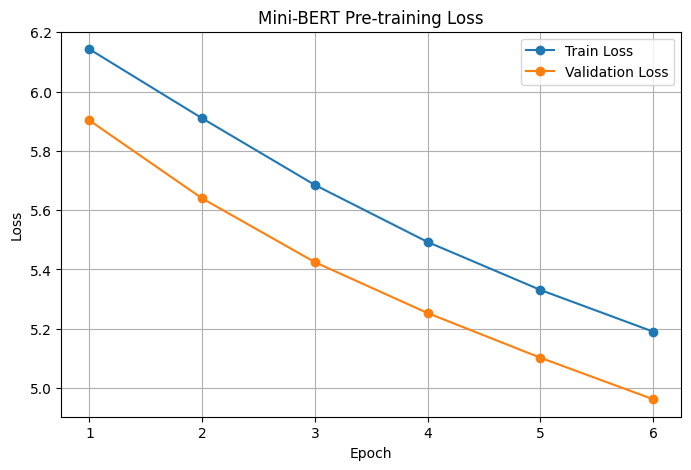

In [66]:
import matplotlib.pyplot as plt

epochs = [
    entry["epoch"]
    for entry in training_history
]

train_losses = [
    entry["train"]["loss"]
    for entry in training_history
]

val_losses = [
    entry["validation"]["loss"]
    for entry in training_history
]

plt.figure(figsize=(8, 5))

plt.plot(epochs, train_losses, marker="o", label="Train Loss")
plt.plot(epochs, val_losses, marker="o", label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Mini-BERT Pre-training Loss")
plt.legend()
plt.grid(True)
plt.show()

## 42. Loading the Best Checkpoint

We will restore the model parameters from the checkpoint with the lowest validation loss.

In [67]:
checkpoint = torch.load(
    "/content/mini_bert_checkpoints/best_model.pt",
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.to(device)
model.eval()

print(
    f"Loaded checkpoint from epoch "
    f"{checkpoint['epoch']}"
)

print(
    f"Best validation loss: "
    f"{checkpoint['best_val_loss']:.4f}"
)

Loaded checkpoint from epoch 6
Best validation loss: 4.9624


## 43. Preparing a Masked Prediction Example

We will mask selected tokens and inspect the model's top predictions.

In [68]:
import torch.nn.functional as F

def predict_masked_tokens(text_a, text_b=None, top_k=5):
    encoded_input = encode_bert_input(
        text_a,
        text_b
    )

    original_ids = encoded_input["input_ids"].clone()

    masked_ids, labels = create_mlm_inputs(
        original_ids,
        special_token_ids
    )

    model_inputs = {
        key: value.unsqueeze(0).to(device)
        for key, value in encoded_input.items()
    }

    model_inputs["input_ids"] = masked_ids.unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(**model_inputs)

    probabilities = F.softmax(
        outputs["mlm_logits"],
        dim=-1
    )

    masked_positions = (labels != -100).nonzero(
        as_tuple=True
    )[0]

    for position in masked_positions:
        token_probabilities = probabilities[
            0,
            position
        ]

        top_probabilities, top_indices = torch.topk(
            token_probabilities,
            top_k
        )

        print(f"\nPosition: {position.item()}")
        print(
            "Original token:",
            tokenizer.id_to_token(
                labels[position].item()
            )
        )

        print("Predictions:")

        for probability, token_id in zip(
            top_probabilities,
            top_indices
        ):
            token = tokenizer.id_to_token(
                token_id.item()
            )

            print(
                f"{token}: "
                f"{probability.item():.4f}"
            )

## 44.Running MLM Evaluation

The model was trained on a limited corpus, so predictions may be imperfect. We will use this evaluation to inspect whether the model learned useful token-level patterns.

In [69]:
predict_masked_tokens(
    "The financial market is influenced by economic conditions."
)

## 45. Evaluating NSP Predictions

We will evaluate whether the model distinguishes a true consecutive sentence pair from a randomly paired sentence.

In [70]:
@torch.no_grad()
def predict_nsp(text_a, text_b):
    encoded_input = encode_bert_input(
        text_a,
        text_b
    )

    model_inputs = {
        key: value.unsqueeze(0).to(device)
        for key, value in encoded_input.items()
    }

    outputs = model(**model_inputs)

    probabilities = F.softmax(
        outputs["nsp_logits"],
        dim=-1
    )

    predicted_label = torch.argmax(
        probabilities,
        dim=-1
    ).item()

    return {
        "predicted_label": predicted_label,
        "probabilities": probabilities[0].cpu()
    }

## 46. Testing NSP Predictions

Label meanings:

* 1: Sentence B is the next sentence.

* 0: Sentence B is not the next sentence.

In [71]:
example = nsp_examples[0]

result = predict_nsp(
    example["sentence_a"],
    example["sentence_b"]
)

print("Sentence A:")
print(example["sentence_a"])

print("\nSentence B:")
print(example["sentence_b"])

print("\nActual label:")
print(example["next_sentence_label"])

print("\nPredicted label:")
print(result["predicted_label"])

print("\nClass probabilities:")
print(result["probabilities"])

Sentence A:
On Her Majesty 's Secret Service was the intended next film , but the producers decided to adapt You Only Live Twice instead because OHMSS would require searching for high and snowy locations .

Sentence B:
The vehicles fill a number of military roles , including that of armoured Infantry Mobility Vehicle , and certain models are available for export as well as for the civilian market .

Actual label:
0

Predicted label:
0

Class probabilities:
tensor([0.9839, 0.0161])


## 47. Calculating NSP Validation Accuracy

We will calculate NSP accuracy on the validation dataset. This metric only measures the NSP classification task.

In [72]:
@torch.no_grad()
def calculate_nsp_accuracy(examples):
    correct = 0

    for example in examples:
        result = predict_nsp(
            example["sentence_a"],
            example["sentence_b"]
        )

        if result["predicted_label"] == example[
            "next_sentence_label"
        ]:
            correct += 1

    return correct / len(examples)


nsp_accuracy = calculate_nsp_accuracy(val_examples)

print(f"NSP validation accuracy: {nsp_accuracy:.4f}")

NSP validation accuracy: 0.7352


## 48. Final Evaluation Summary

We will record the final validation metrics for future comparison.

In [73]:
final_metrics = evaluate(
    model,
    val_loader
)

print("Final validation metrics:")

for metric, value in final_metrics.items():
    print(f"{metric}: {value:.4f}")

print(f"NSP accuracy: {nsp_accuracy:.4f}")

Final validation metrics:
loss: 4.9673
mlm_loss: 4.4275
nsp_loss: 0.5398
NSP accuracy: 0.7352


## 49. Establishing a Baseline

We will record the trained model's validation metrics as the baseline for future experiments.

In [74]:
baseline_results = {
    "model": "Mini-BERT",
    "hidden_size": config.hidden_size,
    "layers": config.num_hidden_layers,
    "attention_heads": config.num_attention_heads,
    "vocab_size": config.vocab_size,
    "max_length": MAX_LENGTH,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "validation_loss": final_metrics["loss"],
    "mlm_loss": final_metrics["mlm_loss"],
    "nsp_loss": final_metrics["nsp_loss"],
    "nsp_accuracy": nsp_accuracy
}

for key, value in baseline_results.items():
    print(f"{key}: {value}")

model: Mini-BERT
hidden_size: 256
layers: 4
attention_heads: 4
vocab_size: 8000
max_length: 128
epochs: 6
batch_size: 16
validation_loss: 4.967345846033542
mlm_loss: 4.427536650610119
nsp_loss: 0.5398091945182126
nsp_accuracy: 0.7351593722585047


## 50. Saving the Experiment Results

We will save the model configuration, training history, and evaluation metrics for documentation and comparison.

In [75]:
import json

results_path = "/content/mini_bert_checkpoints/results.json"

experiment_results = {
    "configuration": config.__dict__,
    "training": {
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY
    },
    "history": training_history,
    "evaluation": baseline_results
}

with open(results_path, "w") as file:
    json.dump(experiment_results, file, indent=4)

print(f"Results saved to: {results_path}")

Results saved to: /content/mini_bert_checkpoints/results.json


## 51. Inspecting Model Predictions

We will inspect several masked-token predictions to identify common errors.

Consider:

* Whether predictions are grammatically plausible.
* Whether predicted tokens fit the context.
* Whether the model predicts frequent but uninformative words.
* Whether the model correctly predicts the original token.

In [76]:
evaluation_sentences = [
    (
        "The financial market is influenced by economic conditions.",
        None
    ),
    (
        "Machine learning models learn patterns from data.",
        None
    ),
    (
        "The company reported strong growth during the year.",
        None
    )
]

for text_a, text_b in evaluation_sentences:
    print("=" * 70)
    print(f"Input: {text_a}")

    predict_masked_tokens(
        text_a,
        text_b,
        top_k=5
    )

Input: The financial market is influenced by economic conditions.

Position: 1
Original token: the
Predictions:
the: 0.6998
in: 0.0287
a: 0.0216
this: 0.0097
": 0.0052

Position: 6
Original token: by
Predictions:
in: 0.2565
by: 0.1576
the: 0.0766
to: 0.0708
for: 0.0436
Input: Machine learning models learn patterns from data.
Input: The company reported strong growth during the year.

Position: 5
Original token: growth
Predictions:
##ed: 0.1217
##s: 0.0772
##ly: 0.0417
out: 0.0195
##ened: 0.0142


## 52. Final Project Summary

This project implemented a miniature BERT pre-training pipeline containing:

* Custom WordPiece tokenizer
* Token, position, and segment embeddings
* Multi-head self-attention
* Transformer encoder layers
* Masked Language Modeling
* Next Sentence Prediction
* Combined pre-training loss
* Training and validation
* Model checkpointing
* Qualitative evaluation

The model is a scaled-down educational implementation and is not expected to match the performance of the original BERT models trained on large corpora.

In [77]:
print("Mini-BERT project completed.")
print("- Custom tokenizer")
print("- Transformer encoder")
print("- MLM objective")
print("- NSP objective")
print("- Training and validation")
print("- Checkpointing")
print("- Qualitative evaluation")
print("- Experiment results")

Mini-BERT project completed.
- Custom tokenizer
- Transformer encoder
- MLM objective
- NSP objective
- Training and validation
- Checkpointing
- Qualitative evaluation
- Experiment results
